In [2]:
import sys
import os
import matplotlib.pyplot as plt
codedir = "../src/"
sys.path.append(os.path.abspath(codedir))

import smplotlib 
from Vlasov_integrators_thick_disk import *



# Figure 8

In [3]:
sim = Gas_plus_stars_integrator(
    kx=0.0, kyc=0.5, Sigma_s= 0.159155, Sigma_g = 0.0,
    kappa= 1.0, Omega0= 0.707107, sigma_x = 0.748665, cssq = 0.0, Hg = 0.0, Hs = 0.0, G= 1)


t_grid = np.linspace(-30, 10, 301)
results = sim.solve(t_grid, fext_params={'delta': 0.0}, impulse_params = {"t_0": 0, "Sigma_impluse" : 0})

# Calculate final surface density using the new class method
surface_densities = sim.get_stellar_surface_density(results, t_grid)

Elapsed time: 0.0796 seconds


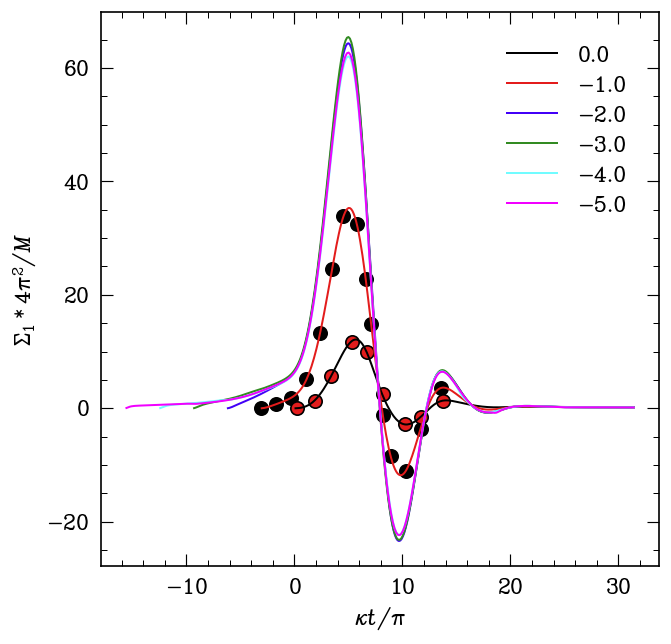

In [10]:
import time

start = time.perf_counter()

counter = 0
for ti_ in np.array([0, -1, -2, -3, -4, -5])*np.pi:

    t_grid = np.linspace(ti_, 10*np.pi, 301)
    results = sim.solve(t_grid, fext_params={'delta': 0.0}, impulse_params = {"t_0": 0, "Sigma_impluse" : 0})

    surface_densities = sim.get_stellar_surface_density(results, t_grid)

    # Multiplying by 4*np.pi**2 because our Fourier transform conventions differ by this factor.
    
    plt.plot(t_grid[1:],surface_densities*(4*np.pi**2), label = ti_/np.pi) 

    counter +=1

binney_minus1_x = np.array([-0.994475138, -0.552486188, -0.110497238, 0.3462246777163904, 0.7513812154696136, 1.1123388581952125, 1.4290976058931864, 1.841620626151013, 2.106813996316759, 2.268876611418048, 2.6151012891344396, 2.843462246777165, 3.285451197053407, 3.727440147329651, 4.331491712707182])
binney_minus1_y = np.array([0, 0.7407407407407476, 1.8518518518518619, 5.1851851851851904, 13.209876543209887, 24.567901234567906, 33.827160493827165, 32.46913580246914, 22.839506172839506, 14.93827160493828, -1.111111111, -8.395061728, -11.1111111, -3.580246914, 3.580246913580254])
plt.scatter(binney_minus1_x*np.pi, binney_minus1_y)
binney_0_x = np.array([0.08839779005524880, 0.5966850828729280, 1.0828729281768000, 1.686924493554330, 2.1362799263351800, 2.6003683241252300, 3.2707182320442, 3.742173112338860, 4.3683241252302000])
binney_0_y = np.array([0, 1.3580246913580300, 5.679012345679010, 11.728395061728400, 9.876543209876540, 2.4691358024691400, -2.839506172839490, -1.481481481481480, 1.3580246913580300])
plt.scatter(binney_0_x*np.pi, binney_0_y)

end = time.perf_counter()

plt.legend()
plt.ylabel(r'$\Sigma_1 * 4\pi^2 / M$')
plt.xlabel(r'$\kappa t/\pi$')
print(f"Elapsed time: {end - start:0.4f} seconds")